Homework 1 - MAE 269

Part 1 - Download and install Python

In [116]:
import sympy as sp
import numpy as np
from scipy.optimize import minimize

In [117]:
# Defining Symbols
l1,l2 = sp.symbols('l1 l2', real=True, positive=True)
theta1, theta2 = sp.symbols('theta1 theta2', real=True)

# Defining time derivatives
theta1_dot, theta2_dot = sp.symbols('theta1_dot theta2_dot', real=True)

In [118]:
# Function that takes in parameters x, y, & theta and returns a 2D transformation matrix T
def T2D(x, y, theta):
    return sp.Matrix([
        [sp.cos(theta), -sp.sin(theta), x],
        [sp.sin(theta),  sp.cos(theta), y],
        [0,              0,             1]
    ])

In [119]:
# Testing Function
T_test = T2D(1,1,theta1)
T_test

Matrix([
[cos(theta1), -sin(theta1), 1],
[sin(theta1),  cos(theta1), 1],
[          0,            0, 1]])

In [120]:
# Transformation to mass 1
T_0_1 = T2D(l1 * sp.cos(theta1), l1 * sp.sin(theta1), theta1)
T_0_1

Matrix([
[cos(theta1), -sin(theta1), l1*cos(theta1)],
[sin(theta1),  cos(theta1), l1*sin(theta1)],
[          0,            0,              1]])

In [121]:
# Transformation from mass 1 to mass 2
T_1_2 = T2D(l2 * sp.cos(theta2), l2 * sp.sin(theta2), theta2)
T_1_2

Matrix([
[cos(theta2), -sin(theta2), l2*cos(theta2)],
[sin(theta2),  cos(theta2), l2*sin(theta2)],
[          0,            0,              1]])

In [122]:
# Transformation to mass 2
T_0_2 = sp.simplify(T_0_1 * T_1_2)
T_0_2

Matrix([
[cos(theta1 + theta2), -sin(theta1 + theta2), l1*cos(theta1) + l2*cos(theta1 + theta2)],
[sin(theta1 + theta2),  cos(theta1 + theta2), l1*sin(theta1) + l2*sin(theta1 + theta2)],
[                   0,                     0,                                        1]])

In [123]:
# Defining time-dependent joint variables
t = sp.symbols('t')

theta1_t = sp.Function('theta1')(t)
theta2_t = sp.Function('theta2')(t)

# Time-dependent transformation matrices
T_0_1_t = T2D(l1 * sp.cos(theta1_t), l1 * sp.sin(theta1_t), theta1_t)
T_1_2_t = T2D(l2 * sp.cos(theta2_t), l2 * sp.sin(theta2_t), theta2_t)
T_0_2_t = sp.simplify(T_0_1_t * T_1_2_t)

In [124]:
# Defining body twist for mass 1
Vb1_mat = sp.simplify(T_0_1_t.inv() * sp.diff(T_0_1_t, t))
# sp.pprint(Vb1_mat) I don't like the display of sp.pprint it looks funky

Vb1 = sp.Matrix([
    Vb1_mat[1, 0],   # omega_z
    Vb1_mat[0, 2],   # v_x
    Vb1_mat[1, 2]    # v_y
])

Vb1 = sp.simplify(Vb1)
# sp.pprint(Vb1)

In [125]:
Vb1_mat

Matrix([
[                       0, -Derivative(theta1(t), t),                           0],
[Derivative(theta1(t), t),                         0, l1*Derivative(theta1(t), t)],
[                       0,                         0,                           0]])

In [126]:
Vb1

Matrix([
[   Derivative(theta1(t), t)],
[                          0],
[l1*Derivative(theta1(t), t)]])

In [127]:
# Defining body twist for mass 2
Vb2_mat = sp.simplify(T_0_2_t.inv() * sp.diff(T_0_2_t, t))
# sp.pprint(Vb2_mat)

Vb2 = sp.Matrix([
    Vb2_mat[1, 0],   # omega_z
    Vb2_mat[0, 2],   # v_x
    Vb2_mat[1, 2]    # v_y
])

Vb2 = sp.simplify(Vb2)
# sp.pprint(Vb2) 

In [128]:
Vb2_mat

Matrix([
[                                                  0, -Derivative(theta1(t), t) - Derivative(theta2(t), t),                                                             l1*sin(theta2(t))*Derivative(theta1(t), t)],
[Derivative(theta1(t), t) + Derivative(theta2(t), t),                                                    0, l1*cos(theta2(t))*Derivative(theta1(t), t) + l2*Derivative(theta1(t), t) + l2*Derivative(theta2(t), t)],
[                                                  0,                                                    0,                                                                                                      0]])

In [129]:
Vb2

Matrix([
[                                                   Derivative(theta1(t), t) + Derivative(theta2(t), t)],
[                                                            l1*sin(theta2(t))*Derivative(theta1(t), t)],
[l1*cos(theta2(t))*Derivative(theta1(t), t) + l2*Derivative(theta1(t), t) + l2*Derivative(theta2(t), t)]])

In [130]:
# Replacing time derivatives with symbolic thetas
subs_dict = {
    sp.diff(theta1_t, t): theta1_dot,
    sp.diff(theta2_t, t): theta2_dot,
    theta1_t: theta1,
    theta2_t: theta2
}

Vb1_sym = sp.simplify(Vb1.subs(subs_dict))
Vb2_sym = sp.simplify(Vb2.subs(subs_dict))

# sp.pprint(Vb1_sym)
# sp.pprint(Vb2_sym)

In [131]:
Vb1_sym

Matrix([
[   theta1_dot],
[            0],
[l1*theta1_dot]])

In [132]:
Vb2_sym

Matrix([
[                                  theta1_dot + theta2_dot],
[                                l1*theta1_dot*sin(theta2)],
[l1*theta1_dot*cos(theta2) + l2*theta1_dot + l2*theta2_dot]])

In [133]:
# Defining Jacobian for mass 1
qdot = sp.Matrix([theta1_dot, theta2_dot])

Jb1 = Vb1_sym.jacobian(qdot)
Jb1 = sp.simplify(Jb1)

# print("Jb1 =")
# sp.pprint(Jb1)

# Defining Jacobian for mass 2
Jb2 = Vb2_sym.jacobian(qdot)
Jb2 = sp.simplify(Jb2)

# print("Jb2 =")
# sp.pprint(Jb2)

In [134]:
Jb1

Matrix([
[ 1, 0],
[ 0, 0],
[l1, 0]])

In [135]:
Jb2

Matrix([
[                  1,  1],
[     l1*sin(theta2),  0],
[l1*cos(theta2) + l2, l2]])

In [136]:
# Defining a function for the world-frame position of mass 2 (end-effector)
p2 = sp.Matrix([
    T_0_2[0, 2], # x_d
    T_0_2[1, 2]  # y_d
])

p2
# sp.pprint(p2)

Matrix([
[l1*cos(theta1) + l2*cos(theta1 + theta2)],
[l1*sin(theta1) + l2*sin(theta1 + theta2)]])

In [137]:
# Converting symbolic expression into numerical function
p2_func = sp.lambdify((l1, l2, theta1, theta2), p2, 'numpy')
print(p2_func(1.0, 1.0, np.pi/4, np.pi/4))

[[0.70710678]
 [1.70710678]]


In [138]:
# Inverse kinematics in order for the end-effector to reach some desired point (x,y)

# Desired target
xd, yd = 1.2, 0.8

# Link lengths
l1_val = 1.0
l2_val = 1.0

# Inverse Kinematic Function
def ik_objective(q):
    th1, th2 = q
    pos = np.array(p2_func(l1_val, l2_val, th1, th2), dtype=float).flatten()
    error = pos - np.array([xd, yd])
    return np.dot(error, error)


q0 = np.array([0.5, 0.5])

result = minimize(ik_objective, q0)

print("Optimization success:", result.success)
print("Optimal joint angles:", result.x)

final_pos = np.array(p2_func(l1_val, l2_val, result.x[0], result.x[1]), dtype=float).flatten()
print("Final end-effector position:", final_pos)
print("Desired position:", [xd, yd])


Optimization success: True
Optimal joint angles: [-0.17739072  1.53078645]
Final end-effector position: [1.19999962 0.79999957]
Desired position: [1.2, 0.8]


Part 3 - Exploring properties of rotations and transformations in Python

In [139]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Skew-Symmetric Matrix Function
def skew(n):
    nx, ny, nz = n
    return np.array([
        [0,   -nz,  ny],
        [nz,   0,  -nx],
        [-ny, nx,   0]
    ])
    
# Defining random rotation matrix function
def random_rotation():
    # Random axis
    n = np.random.randn(3)
    n = n / np.linalg.norm(n)

    # Random angle between 0 and 2*pi
    theta = np.random.uniform(0, 2 * np.pi)

    # Rodrigues formula
    n_hat = skew(n)
    R = np.eye(3) + np.sin(theta) * n_hat + (1 - np.cos(theta)) * (n_hat @ n_hat)

    return R

In [140]:
# Testing Function
R = random_rotation()
print(R)
print("det(R) =", np.linalg.det(R))

[[ 0.9872362  -0.1342742  -0.08564533]
 [ 0.12483145  0.98634294 -0.10744635]
 [ 0.09890293  0.09538369  0.9905151 ]]
det(R) = 0.9999999999999997


In [141]:
# Generating 9 random rotation matrices and computing its determinants
rotations = [random_rotation() for _ in range(9)]
dets = [np.linalg.det(R) for R in rotations]

for i, det_val in enumerate(dets, 1):
    print(f"Rotation {i}: det = {det_val:.6f}")

Rotation 1: det = 1.000000
Rotation 2: det = 1.000000
Rotation 3: det = 1.000000
Rotation 4: det = 1.000000
Rotation 5: det = 1.000000
Rotation 6: det = 1.000000
Rotation 7: det = 1.000000
Rotation 8: det = 1.000000
Rotation 9: det = 1.000000


In [156]:
# Defining frame plot function
def frame_plot(ax, R):
    origin = np.zeros(3)

    # World frame axes in black
    ax.quiver(*origin, 1, 0, 0, color='k')
    ax.quiver(*origin, 0, 1, 0, color='k')
    ax.quiver(*origin, 0, 0, 1, color='k')

    # Rotated frame axes in blue
    ax.quiver(*origin, *R[:, 0], color='b')
    ax.quiver(*origin, *R[:, 1], color='b')
    ax.quiver(*origin, *R[:, 2], color='b')

    #ax.set_xlim([-1, 1])
    #ax.set_ylim([-1, 1])
    #ax.set_zlim([-1, 1])

    # Use this in order to set the range for each axis you could set an array with these values 
    vals = np.linspace(-1, 1, 5)
    ax.set_xticks(vals)
    ax.set_yticks(vals)
    ax.set_zticks(vals)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

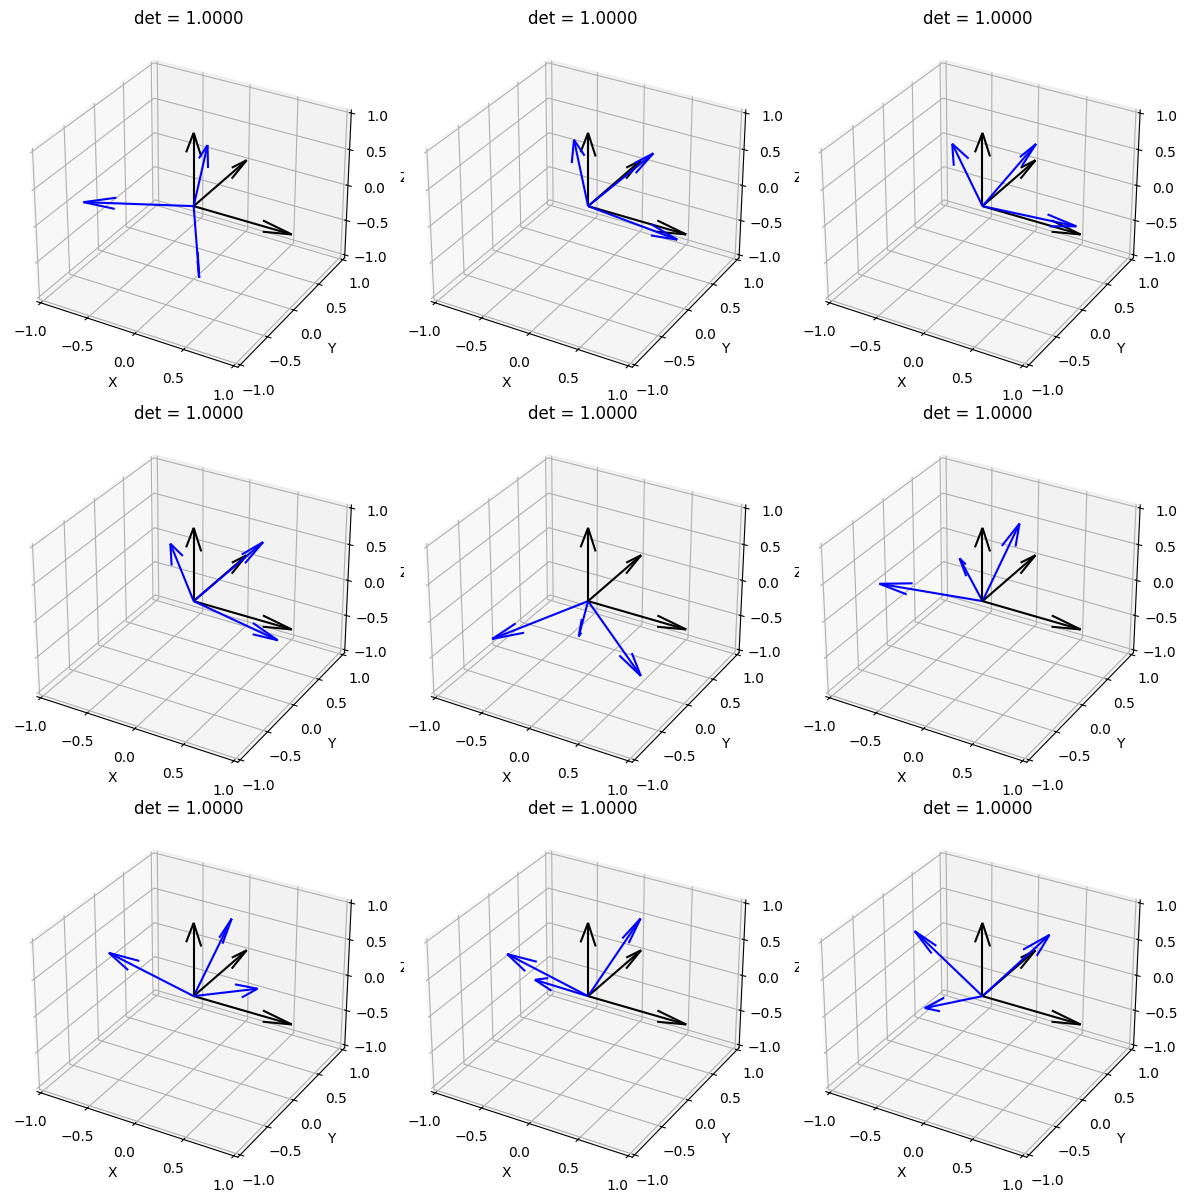

In [157]:
# Plotting 9 random frames
fig = plt.figure(figsize=(12, 12))

for i in range(9):
    ax = fig.add_subplot(3, 3, i + 1, projection='3d')
    R = random_rotation()
    frame_plot(ax, R)
    ax.set_title(f"det = {np.linalg.det(R):.4f}")

plt.tight_layout()
plt.show()

In [158]:
# Defining function to create random transformations
def random_transform():
    R = random_rotation()
    p = np.random.randn(3)
    
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T
    
# Defining function for plotting SE(3) 4x4 transformation matrix (T)
def plot_transform(T):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    origin = np.zeros(3)
    p = T[:3, 3]
    R = T[:3, :3]

    # Line from world origin to transform origin
    ax.plot([0, p[0]], [0, p[1]], [0, p[2]], 'k-')

    # World frame
    ax.quiver(0, 0, 0, 1, 0, 0, color='k')
    ax.quiver(0, 0, 0, 0, 1, 0, color='k')
    ax.quiver(0, 0, 0, 0, 0, 1, color='k')

    # Frame at T origin
    ax.quiver(*p, *R[:, 0], color='r')
    ax.quiver(*p, *R[:, 1], color='g')
    ax.quiver(*p, *R[:, 2], color='b')

    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

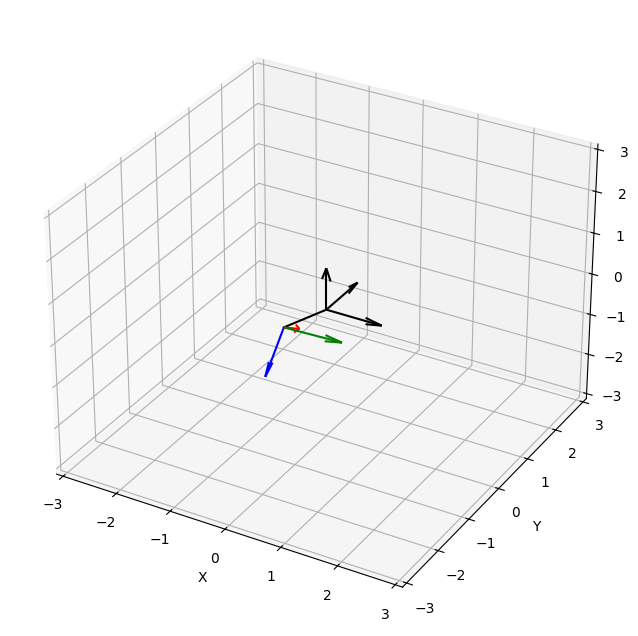

Translation vector:
[-0.76146054 -0.0348727  -0.70453888]

Rotation matrix:
[[-0.1649663   0.98601781  0.0235586 ]
 [ 0.76676128  0.14323425 -0.62574843]
 [-0.62037349 -0.08516358 -0.7796691 ]]


In [145]:
# Generating and plotting one random transformation matrix
T = random_transform()
plot_transform(T)

print("Translation vector:")
print(T[:3, 3])

print("\nRotation matrix:")
print(T[:3, :3])

In [159]:
# Generating a random homogeneous vector and verify the length remains the same after applying a transformation
v = np.random.randn(3) # random 3D vector
R = T[:3, :3]          # transformation

v_rot = R @ v          # rotated vector

# Comparing its lengths
print("Original length:", np.linalg.norm(v))
print("Rotated length: ", np.linalg.norm(v_rot))

Original length: 0.9738699020384367
Rotated length:  0.9738699020384366
